Лабораторная работа 6

Выполнила студентка группы 6131-010402D Фролова Анастасия Сергеевна

1:

Считать в pandas.DataFrame любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.


In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from matplotlib import pyplot as plt

import sklearn as sk
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('loan_data.csv')

2:

Датасет и подготовка данных:


Привести описание датасета.


Датасет содержит записи о персональных и финансовых данных. Эти данные используются для понимания факторов финансового риска и моделирования процессов прогнозного моделирования для одобрения кредитов и кредитного скоринга.
* person_age - возраст;
* person_gender - пол;
* person_education - наивысший уровень образования;
* person_income - годовой доход;
* person_emp_exp - количество лет трудового стажа;
* person_home_ownership - статус владения жильем (аренда, собственное, ипотека);
* loan_amnt - запрашиваемая сумма кредита;
* loan_intent — цель кредита;
* loan_int_rate — процентная ставка по кредиту;
* loan_percent_income — сумма кредита в процентах от годового дохода;
* cb_person_cred_hist_length — продолжительность кредитной истории в годах;
* credit_score — кредитный рейтинг человека;
* previous_loan_defaults_on_file — индикатор предыдущих невыплат кредита;
* loan_status — статус одобрения кредита (1 = одобрено; 0 = отклонено).

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Осуществить предобработку данных (избавиться от null, убрать некоторые признаки и т.п.) - "подчистить данные".


In [4]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [5]:
print(df['person_gender'].unique())
print(df['person_education'].unique())
print(df['person_home_ownership'].unique())
print(df['loan_intent'].unique())
print(df['previous_loan_defaults_on_file'].unique())

['female' 'male']
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['No' 'Yes']


In [6]:
# Заменим категориальные признаки

columns = {'person_gender': {'female': 1, 'male': 0},
           'person_education': {'Master': 0, 'High School': 1, 'Bachelor': 2, 'Associate': 3, 'Doctorate': 4},
           'person_home_ownership': {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3},
           'loan_intent': {'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2, 'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5},
           'previous_loan_defaults_on_file': {'No': 0, 'Yes': 1}}
df_replace = df.replace(columns)

<ipython-input-6-6eb6e28ee8c7>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_replace = df.replace(columns)


In [7]:
print(df_replace.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  int64  
 2   person_education                45000 non-null  int64  
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  int64  
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  int64  
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

Нормализовать численные данные.


Разбить выборку на обучающую и тестовую.


In [8]:
X = df_replace.drop('loan_status', axis=1)
y = df_replace['loan_status']

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(X)
X = pd.DataFrame(scaled_features, columns=X.columns)
y = scaler.fit_transform(y.values.reshape(-1,1)).flatten()

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X,y, test_size= 0.3, random_state= 42)

In [9]:
# Формируем второй датасет как есть

col = [df.columns[i] for i in range(df.shape[1]) if df.dtypes[df.columns[i]] != 'object']
print(col)

['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']


In [10]:
df_as_is = df.copy()

scaler = MinMaxScaler()
scaler.fit(df_as_is[col])
df_as_is[col] = scaler.transform(df_as_is[col])
df_as_is.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,0.016129,female,Master,0.008891,0.000,RENT,1.000000,PERSONAL,0.727023,0.742424,0.035714,0.371739,No,1.0
1,0.008065,female,High School,0.000595,0.000,OWN,0.014493,EDUCATION,0.392318,0.121212,0.000000,0.247826,Yes,0.0
2,0.040323,female,High School,0.000617,0.024,MORTGAGE,0.144928,MEDICAL,0.510974,0.666667,0.035714,0.532609,No,1.0
3,0.024194,female,Bachelor,0.009976,0.000,RENT,1.000000,MEDICAL,0.672840,0.666667,0.000000,0.619565,No,1.0
4,0.032258,male,Master,0.008082,0.008,RENT,1.000000,MEDICAL,0.606996,0.803030,0.071429,0.426087,No,1.0


In [11]:
X_as_is = df_as_is.drop('loan_status', axis=1)
y_as_is = df_as_is['loan_status']

X_train_as_is, X_test_as_is, y_train_as_is, y_test_as_is = train_test_split(X_as_is,y_as_is, test_size= 0.3, random_state= 42)

3:

Для каждого из классификаторов (AdaBoostClassifier, GradientBoostingClassifier, XGBClassifier, CatBoostClassifier)

С использованием GridSearchCV/grid_search осуществить подбор гиперпараметра модели, использовать выборки с закодированными категориальными признаками.

In [12]:
!pip install catboost

In [13]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [14]:
import catboost
from catboost import CatBoostClassifier

In [15]:
from sklearn.metrics import classification_report

In [16]:
# AdaBoost

ADA = AdaBoostClassifier(n_estimators= 50, learning_rate= 1.0, algorithm="SAMME", random_state= 42)
ADA.fit(X_train_cat, y_train_cat)
y_predict = ADA.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict))

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     10493
         1.0       0.83      0.76      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.88      0.86      0.87     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Модель хорошо предсказывает класс 0 и также 1, хоть и несколько хуже, однако все же стоит подобрать гиперпараметры для лучшей модели

In [17]:
ada_grid = {
    'n_estimators': range(10, 50, 10),  # количество деревьев в ансамбле
    'learning_rate': np.arange(0.01, 1, 0.1),  # скорость обучения
}

ada_grid_search = GridSearchCV(ADA, ada_grid, cv = 5, verbose= 2, n_jobs= -1)
ada_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(algorithm='SAMME', random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01, 0.11, 0.21, 0.31, 0.41, 0.51, 0.61, 0.71, 0.81, 0.91]),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [18]:
ada_grid_search.best_params_

{'learning_rate': 0.91, 'n_estimators': 40}

In [19]:
y_predict_ada = ada_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_ada))

              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94     10493
         1.0       0.80      0.77      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.86      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# После подбора гиперпараметров результат почти не изменился

In [20]:
# GradientBoostingClassifier

grad_grid = {
    'n_estimators': range(10, 50, 10),
    'learning_rate': np.arange(0.01, 0.1, 0.1),
    'max_depth': range(1, 6),
}

grad_model = GradientBoostingClassifier()

grad_grid_search = GridSearchCV(grad_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

grad_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [21]:
grad_grid_search.best_params_

{'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 10}

In [22]:
y_predict_grad = grad_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_grad, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Данный классификатор неплохо предсказывает класс 0, однако класс 1 определяется плохо

In [23]:
# XGBoost

# Для начала подберем основные параметры модели

xgb_model = XGBClassifier()

xgb_grid_search = GridSearchCV(xgb_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

xgb_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [24]:
xgb_grid_search.best_params_

{'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 10}

In [25]:
y_predict_xgb = xgb_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_xgb, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [26]:
xgb_model_params = {
    'n_estimators': [10],
    'learning_rate': [0.01],
    'max_depth': [1],
    'gamma': np.arange(0, 1.5, 0.5),
    'lambda': np.arange(0, 2.5, 0.5),
    'alpha': np.arange(0, 1.5, 0.5),
}

xgb_model = XGBClassifier()

xgb_grid_search = GridSearchCV(xgb_model, xgb_model_params, cv = 5, verbose= 2, n_jobs= -1)

xgb_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'alpha': array([0. , 0.5, 1. ]),
                         'gamma': array([0. , 0.5, 1. ]),
                         'lambda': array([0. , 0.5, 1. , 1.5, 2. ]),
                         'learning_rate': [0.01], 'max_depth': [1],
                         'n_estimators': [10]},
             verbose=2)

In [27]:
xgb_grid_search.best_params_

{'alpha': 0.0,
 'gamma': 0.0,
 'lambda': 0.0,
 'learning_rate': 0.01,
 'max_depth': 1,
 'n_estimators': 10}

In [28]:
y_predict_xgb = xgb_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_xgb, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Подбор дополнительных параметров не улучшил результат
# Данный классификатор также неплохо предсказывает класс 0, но с классом 1 проблемы

In [29]:
# CatBoost

cat_model = CatBoostClassifier()

cat_grid_search = GridSearchCV(cat_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

cat_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
0:	learn: 0.6862853	total: 53ms	remaining: 2.07s
1:	learn: 0.6793088	total: 58.4ms	remaining: 1.11s
2:	learn: 0.6724866	total: 62.9ms	remaining: 775ms
3:	learn: 0.6660621	total: 67.6ms	remaining: 609ms
4:	learn: 0.6597554	total: 72.3ms	remaining: 506ms
5:	learn: 0.6536079	total: 77ms	remaining: 436ms
6:	learn: 0.6472511	total: 81.5ms	remaining: 384ms
7:	learn: 0.6411224	total: 86.1ms	remaining: 344ms
8:	learn: 0.6350128	total: 90.8ms	remaining: 313ms
9:	learn: 0.6292152	total: 95.3ms	remaining: 286ms
10:	learn: 0.6235079	total: 100ms	remaining: 265ms
11:	learn: 0.6178746	total: 106ms	remaining: 247ms
12:	learn: 0.6124148	total: 111ms	remaining: 231ms
13:	learn: 0.6069695	total: 117ms	remaining: 217ms
14:	learn: 0.6016682	total: 122ms	remaining: 203ms
15:	learn: 0.5964191	total: 126ms	remaining: 189ms
16:	learn: 0.5913038	total: 131ms	remaining: 177ms
17:	learn: 0.5859858	total: 136ms	remaining: 166ms
18:	learn: 0.5808881	tot

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x7f474ff7e710>,
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [30]:
cat_grid_search.best_params_

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 40}

In [77]:
cat_model_after = CatBoostClassifier(n_estimators=40, max_depth=5, learning_rate=0.01)
cat_model_after.fit(X_train_cat, y_train_cat)

0:	learn: 0.6862853	total: 16.8ms	remaining: 656ms
1:	learn: 0.6793088	total: 24.5ms	remaining: 466ms
2:	learn: 0.6724866	total: 29.6ms	remaining: 365ms
3:	learn: 0.6660621	total: 36ms	remaining: 324ms
4:	learn: 0.6597554	total: 42.9ms	remaining: 300ms
5:	learn: 0.6536079	total: 47.6ms	remaining: 270ms
6:	learn: 0.6472511	total: 53.9ms	remaining: 254ms
7:	learn: 0.6411224	total: 60.3ms	remaining: 241ms
8:	learn: 0.6350128	total: 64.9ms	remaining: 224ms
9:	learn: 0.6292152	total: 71.6ms	remaining: 215ms
10:	learn: 0.6235079	total: 77.9ms	remaining: 205ms
11:	learn: 0.6178746	total: 83.1ms	remaining: 194ms
12:	learn: 0.6124148	total: 89.7ms	remaining: 186ms
13:	learn: 0.6069695	total: 94.6ms	remaining: 176ms
14:	learn: 0.6016682	total: 101ms	remaining: 168ms
15:	learn: 0.5964191	total: 107ms	remaining: 161ms
16:	learn: 0.5913038	total: 113ms	remaining: 153ms
17:	learn: 0.5859858	total: 119ms	remaining: 145ms
18:	learn: 0.5808881	total: 125ms	remaining: 138ms
19:	learn: 0.5758586	total: 1

In [78]:
y_predict_cat = cat_model_after.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     10493
         1.0       0.84      0.73      0.78      3007

    accuracy                           0.91     13500
   macro avg       0.88      0.84      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Результат для класса 0 хороший, однако для класса 1 он несколько хуже

Обучить модели XGBClassifier и CatBoostClassifier
 с найденными гиперпараметрами на обучающей выборке с категориальными признаками "как есть".

In [32]:
import copy
from copy import deepcopy

In [54]:
from catboost import Pool

In [57]:
cat_cols = [var for var in X_train_as_is.columns if X_train_as_is[var].dtype == 'object']

X_cat_train_1 = deepcopy(X_train_as_is)
X_cat_test_1 = deepcopy(X_test_as_is)


for col in cat_cols:
    X_cat_train_1[col] = pd.Categorical(X_cat_train_1[col])
    X_cat_test_1[col] = pd.Categorical(X_cat_test_1[col])

train_data_cat = Pool(data=X_cat_train_1, label=y_train_cat, cat_features=cat_cols)
test_data_cat  = Pool(data=X_cat_test_1, label=y_test_cat, cat_features=cat_cols)

In [58]:
xgb_model_best = XGBClassifier(n_estimators=10, max_depth=1, learning_rate=0.01, alpha=0.0, gamma=0.0, reg_lambda = 0, objective='binary:logistic', enable_categorical=True, max_cat_to_onehot=10000)
xgb_model_best.fit(X_cat_train_1, y_train_cat)
y_ce_pred_xgb = xgb_model_best.predict(X_cat_test_1)
print(classification_report(y_test_cat, y_ce_pred_xgb, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [61]:
cat_model_best = CatBoostClassifier(n_estimators=40, max_depth=5, learning_rate=0.01)
cat_model_best.fit(train_data_cat)
y_ce_pred_cat = cat_model_best.predict(X_cat_test_1)
print(classification_report(y_test_cat, y_ce_pred_cat))

0:	learn: 0.6861750	total: 31.2ms	remaining: 1.22s
1:	learn: 0.6796066	total: 80.9ms	remaining: 1.54s
2:	learn: 0.6729929	total: 112ms	remaining: 1.38s
3:	learn: 0.6665349	total: 170ms	remaining: 1.53s
4:	learn: 0.6601537	total: 217ms	remaining: 1.52s
5:	learn: 0.6540066	total: 256ms	remaining: 1.45s
6:	learn: 0.6480538	total: 290ms	remaining: 1.37s
7:	learn: 0.6421419	total: 337ms	remaining: 1.35s
8:	learn: 0.6363208	total: 375ms	remaining: 1.29s
9:	learn: 0.6305454	total: 403ms	remaining: 1.21s
10:	learn: 0.6249829	total: 428ms	remaining: 1.13s
11:	learn: 0.6194979	total: 451ms	remaining: 1.05s
12:	learn: 0.6139953	total: 485ms	remaining: 1.01s
13:	learn: 0.6086754	total: 509ms	remaining: 945ms
14:	learn: 0.6033926	total: 538ms	remaining: 896ms
15:	learn: 0.5981977	total: 564ms	remaining: 846ms
16:	learn: 0.5931688	total: 601ms	remaining: 813ms
17:	learn: 0.5881837	total: 624ms	remaining: 762ms
18:	learn: 0.5834001	total: 647ms	remaining: 715ms
19:	learn: 0.5788087	total: 682ms	remai

Итого получить 6 обученных моделей.


Вывести метрики на тестовом наборе (как минимум classification_report, другие по желанию).


In [79]:
print("AdaBoostClassifier")
print(classification_report(y_test_cat, y_predict_ada))
print("GradientBoostingClassifier")
print(classification_report(y_test_cat, y_predict_grad, zero_division = 0))
print("XGBClassifier with coded")
print(classification_report(y_test_cat, y_predict_xgb, zero_division = 0))
print("CatBoostClassifier with coded")
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))
print("XGBClassifier with default")
print(classification_report(y_test_cat, y_ce_pred_xgb, zero_division = 0))
print("CatBoostClassifier with default")
print(classification_report(y_test_cat, y_ce_pred_cat))

AdaBoostClassifier
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94     10493
         1.0       0.80      0.77      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.86      0.86     13500
weighted avg       0.91      0.91      0.91     13500

GradientBoostingClassifier
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500

XGBClassifier with coded
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
wei

Сравнить модели, выбрать лучшую.


In [ ]:
# Вывод: Лучший результат показали модели ADABoost и CatBoost с accuracy в 0.91, однако лучшим по метрике precision оказался CatBoost
# Выберем в качестве лучшей модели CatBoostClassifier with coded

4:

Важность признаков:


In [63]:
import shap

С использованием shap.TreeExplainer получить SHAP
-значения для лучшей модели.

In [80]:
tree_explainer = shap.TreeExplainer(cat_model_after)
shap_values = tree_explainer.shap_values(X_train_cat)

Построить график shap.plots.force для одного объекта выборки и для среза произвольного размера.


In [81]:
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, shap_values[0,:], X_train_cat.iloc[0,:])

from IPython.display import HTML
HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

In [82]:
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, shap_values[0:100,:], X_train_cat.iloc[0:100,:])

from IPython.display import HTML
HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

Построить график shap.plots.bar для одного объекта выборки.


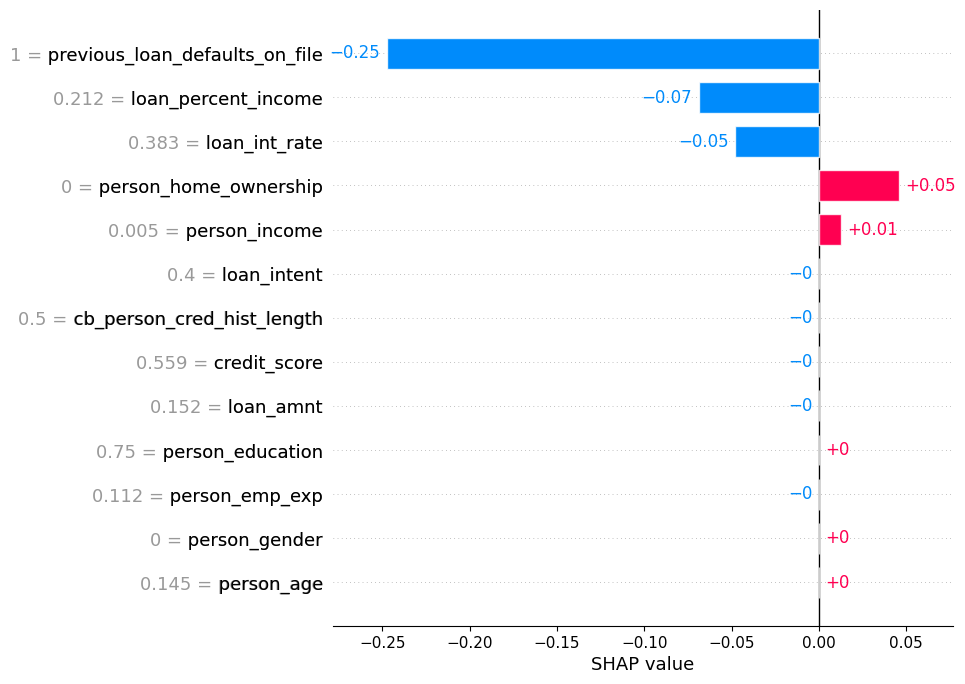

In [85]:
te_df_shap_values  = tree_explainer(X_train_cat)
shap_bp = shap.plots.bar(te_df_shap_values[0], max_display=X_train_cat.shape[1])

Построить график shap.plots.waterfall для одного объекта выборки.


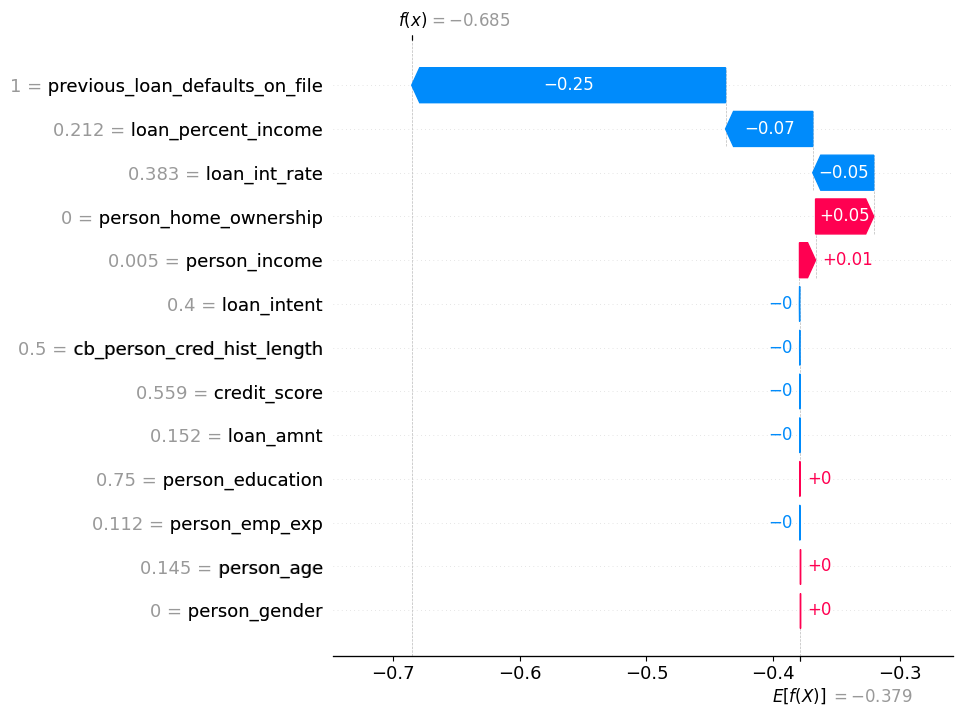

In [86]:
shap.plots.waterfall(te_df_shap_values[0], max_display=X_train_cat.shape[1])

Построить 2 графика shap.plots.scatter для какого-нибудь признака. На одном раскрасить относительно себя, на втором – относительно другого признака.


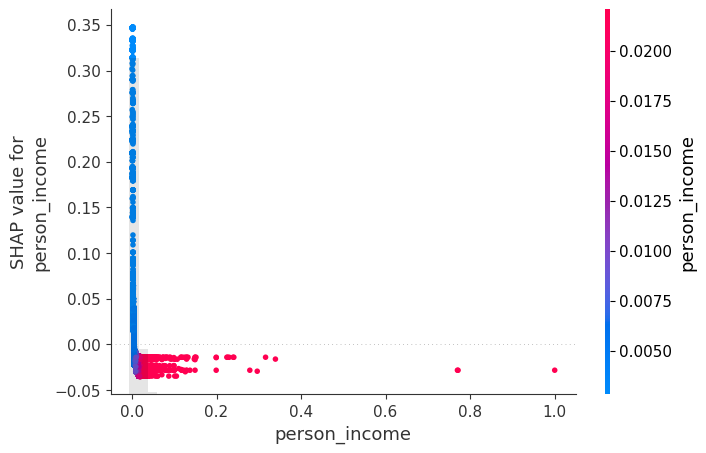

In [87]:
shap.plots.scatter(te_df_shap_values[:, "person_income"], color=te_df_shap_values[:, "person_income"])

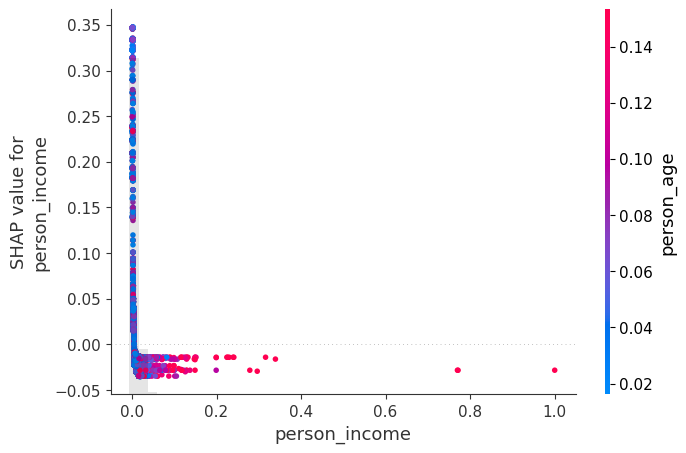

In [88]:
shap.plots.scatter(te_df_shap_values[:, "person_income"], color=te_df_shap_values[:, "person_age"])

Построить график shap.plots.beeswarm для всех признаков.


<Axes: xlabel='SHAP value (impact on model output)'>

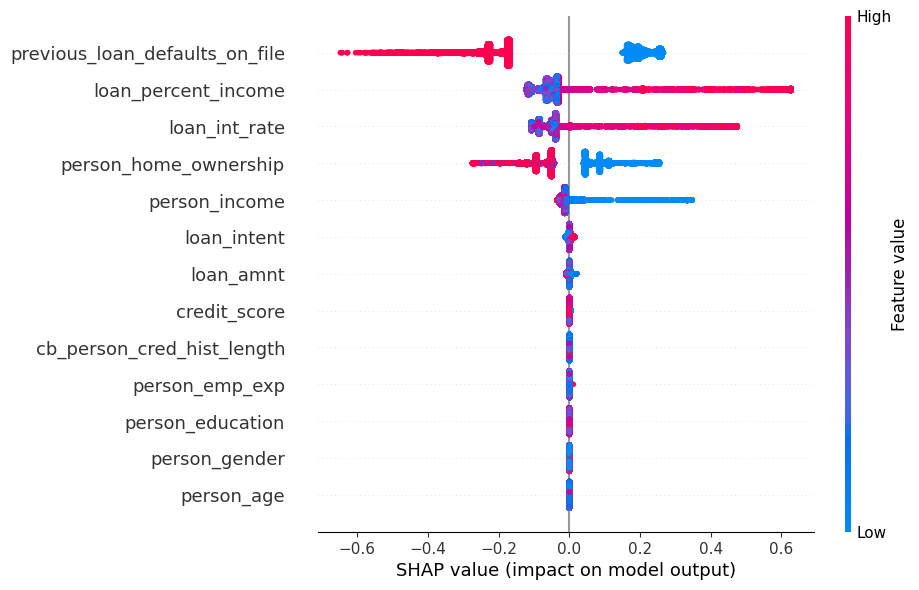

In [89]:
shap.plots.beeswarm(te_df_shap_values, max_display=X_train_cat.shape[1], show=False)

Построить график shap.plots.bar для всех признаков.


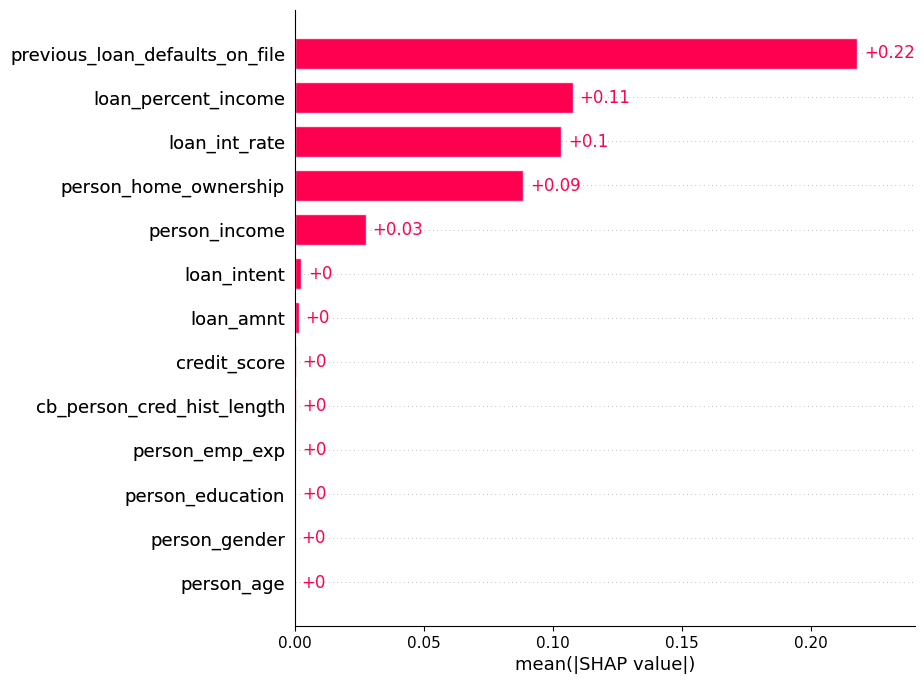

In [90]:
shap.plots.bar(te_df_shap_values, max_display=X_train_cat.shape[1])

На основании двух последних графиков и/или используя feature_importance отфильровать признаки (отразить сформулированные выводы в тексте), переобучить лучшую модель.


In [ ]:
# Оставим признаки с важностью больше 0

In [92]:
filter_cols = ['previous_loan_defaults_on_file','loan_percent_income', 'loan_int_rate', "person_home_ownership", "person_income"]

In [94]:
cat_model_after.fit(X_train_cat[filter_cols], y_train_cat)

0:	learn: 0.6861979	total: 11.9ms	remaining: 466ms
1:	learn: 0.6792889	total: 19.2ms	remaining: 365ms
2:	learn: 0.6724480	total: 23.1ms	remaining: 284ms
3:	learn: 0.6657514	total: 28.6ms	remaining: 258ms
4:	learn: 0.6592958	total: 32.4ms	remaining: 227ms
5:	learn: 0.6529906	total: 37.8ms	remaining: 214ms
6:	learn: 0.6467872	total: 41.8ms	remaining: 197ms
7:	learn: 0.6408631	total: 46.9ms	remaining: 188ms
8:	learn: 0.6347703	total: 51ms	remaining: 176ms
9:	learn: 0.6287271	total: 56.3ms	remaining: 169ms
10:	learn: 0.6231049	total: 63ms	remaining: 166ms
11:	learn: 0.6172887	total: 68.2ms	remaining: 159ms
12:	learn: 0.6117753	total: 72.2ms	remaining: 150ms
13:	learn: 0.6063428	total: 77.6ms	remaining: 144ms
14:	learn: 0.6009535	total: 81.7ms	remaining: 136ms
15:	learn: 0.5956914	total: 87.3ms	remaining: 131ms
16:	learn: 0.5904822	total: 91.1ms	remaining: 123ms
17:	learn: 0.5853033	total: 96.3ms	remaining: 118ms
18:	learn: 0.5803348	total: 105ms	remaining: 116ms
19:	learn: 0.5753422	total:

Сравнить метрики до и после фильтрации.


In [95]:
y_predict_filter = cat_model_after.predict(X_test_cat[filter_cols])
print("Before:")
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))
print("After:")
print(classification_report(y_test_cat, y_predict_filter, zero_division = 0))

Before:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     10493
         1.0       0.84      0.73      0.78      3007

    accuracy                           0.91     13500
   macro avg       0.88      0.84      0.86     13500
weighted avg       0.91      0.91      0.91     13500

After:
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.84      0.74      0.78      3007

    accuracy                           0.91     13500
   macro avg       0.88      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Метрики почти не изменились, разница в сотых в некоторых параметрах, однако количество признаков было уменьшено до 5

Визуализировать полученное дерево решений.


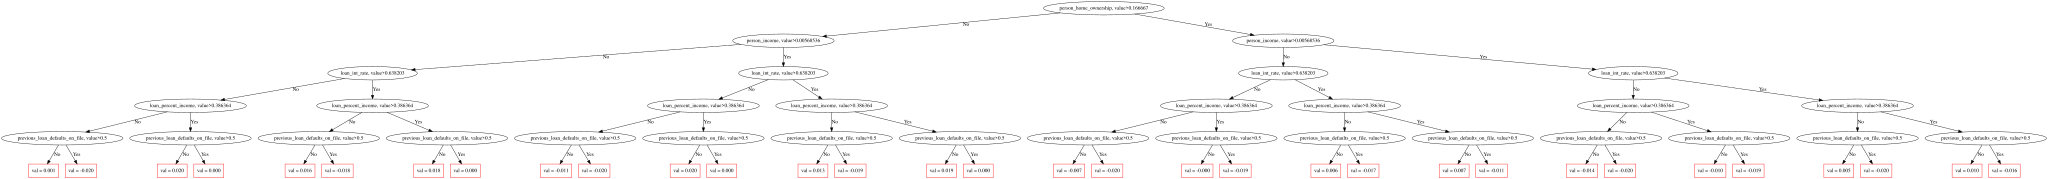

In [96]:
cat_model_after.plot_tree(
    tree_idx=0,
    pool=Pool(data=X_train_cat[filter_cols], label=y_train_cat)
)


5:

Регрессия:


С использованием GridSearchCV/grid_search осуществить подбор гиперпараметра модели линейной регрессии с использованием XGBoost или CatBoost

In [97]:
from catboost import CatBoostRegressor

In [100]:
model = CatBoostRegressor(random_state=42)

CatBoost_param = {
    'iterations': [50, 100],
    'learning_rate': np.arange(0.05, 1.05, 0.05),
    'depth': np.arange(1, 5, 1),
}

model_CatBoostRegressor_grid = GridSearchCV(model, CatBoost_param, cv=5, verbose= 2, n_jobs= -1)
model_CatBoostRegressor_grid.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
0:	learn: 0.3241749	total: 5.5ms	remaining: 544ms
1:	learn: 0.2846218	total: 10.7ms	remaining: 522ms
2:	learn: 0.2699128	total: 14.9ms	remaining: 482ms
3:	learn: 0.2623960	total: 19.1ms	remaining: 460ms
4:	learn: 0.2566979	total: 23.2ms	remaining: 441ms
5:	learn: 0.2536418	total: 27.6ms	remaining: 432ms
6:	learn: 0.2519656	total: 32ms	remaining: 425ms
7:	learn: 0.2507145	total: 36.2ms	remaining: 417ms
8:	learn: 0.2494711	total: 40.5ms	remaining: 409ms
9:	learn: 0.2481359	total: 44.7ms	remaining: 402ms
10:	learn: 0.2474405	total: 48.9ms	remaining: 396ms
11:	learn: 0.2469618	total: 52.7ms	remaining: 387ms
12:	learn: 0.2465087	total: 56.8ms	remaining: 380ms
13:	learn: 0.2461827	total: 60.9ms	remaining: 374ms
14:	learn: 0.2458299	total: 65ms	remaining: 368ms
15:	learn: 0.2452731	total: 69.1ms	remaining: 363ms
16:	learn: 0.2449882	total: 73.1ms	remaining: 357ms
17:	learn: 0.2447429	total: 77ms	remaining: 351ms
18:	learn: 0.24454

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x7f4722e25010>,
             n_jobs=-1,
             param_grid={'depth': array([1, 2, 3, 4]), 'iterations': [50, 100],
                         'learning_rate': array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])},
             verbose=2)

In [101]:
model_CatBoostRegressor_grid.best_params_

{'depth': 4, 'iterations': 100, 'learning_rate': 0.45}

In [102]:
best_reg = CatBoostRegressor(depth=4, learning_rate=0.45, iterations=100, random_state=42)

In [103]:
best_reg.fit(X_train_cat, y_train_cat)

0:	learn: 0.3241749	total: 15.4ms	remaining: 1.53s
1:	learn: 0.2846218	total: 27.5ms	remaining: 1.34s
2:	learn: 0.2699128	total: 38.9ms	remaining: 1.26s
3:	learn: 0.2623960	total: 54.3ms	remaining: 1.3s
4:	learn: 0.2566979	total: 66.3ms	remaining: 1.26s
5:	learn: 0.2536418	total: 81.5ms	remaining: 1.28s
6:	learn: 0.2519656	total: 93.8ms	remaining: 1.25s
7:	learn: 0.2507145	total: 106ms	remaining: 1.21s
8:	learn: 0.2494711	total: 120ms	remaining: 1.21s
9:	learn: 0.2481359	total: 133ms	remaining: 1.2s
10:	learn: 0.2474405	total: 144ms	remaining: 1.16s
11:	learn: 0.2469618	total: 158ms	remaining: 1.16s
12:	learn: 0.2465087	total: 171ms	remaining: 1.15s
13:	learn: 0.2461827	total: 183ms	remaining: 1.13s
14:	learn: 0.2458299	total: 196ms	remaining: 1.11s
15:	learn: 0.2452731	total: 209ms	remaining: 1.1s
16:	learn: 0.2449882	total: 218ms	remaining: 1.06s
17:	learn: 0.2447429	total: 224ms	remaining: 1.02s
18:	learn: 0.2445475	total: 230ms	remaining: 980ms
19:	learn: 0.2438609	total: 235ms	rem

In [104]:
y_pred_reg = best_reg.predict(X_test_cat)

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Вывести метрики MSE, MAE и R2
 на тестовом наборе.

In [107]:
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg):.2f}")

Средняя квадратичная ошибка (MSE): 0.05
Средняя абсолютная ошибка (MAE): 0.13
Коэффициент детерминации (R2): 0.68


Переобучить модель на отфильтрованном наборе признаков из пункта 4.


In [108]:
best_reg.fit(X_train_cat[filter_cols], y_train_cat)

0:	learn: 0.3232681	total: 11.1ms	remaining: 1.09s
1:	learn: 0.2847903	total: 21.8ms	remaining: 1.07s
2:	learn: 0.2697144	total: 37.1ms	remaining: 1.2s
3:	learn: 0.2616371	total: 51.6ms	remaining: 1.24s
4:	learn: 0.2575014	total: 71.3ms	remaining: 1.35s
5:	learn: 0.2553555	total: 82.1ms	remaining: 1.29s
6:	learn: 0.2540414	total: 102ms	remaining: 1.35s
7:	learn: 0.2533503	total: 123ms	remaining: 1.42s
8:	learn: 0.2522863	total: 140ms	remaining: 1.41s
9:	learn: 0.2501501	total: 160ms	remaining: 1.44s
10:	learn: 0.2493138	total: 178ms	remaining: 1.44s
11:	learn: 0.2490780	total: 188ms	remaining: 1.38s
12:	learn: 0.2488803	total: 205ms	remaining: 1.37s
13:	learn: 0.2486977	total: 221ms	remaining: 1.35s
14:	learn: 0.2482144	total: 237ms	remaining: 1.34s
15:	learn: 0.2478642	total: 261ms	remaining: 1.37s
16:	learn: 0.2475797	total: 278ms	remaining: 1.35s
17:	learn: 0.2470590	total: 296ms	remaining: 1.35s
18:	learn: 0.2467958	total: 310ms	remaining: 1.32s
19:	learn: 0.2461857	total: 324ms	re

In [109]:
y_pred_reg_fil = best_reg.predict(X_test_cat)

Сравнить метрики до и после фильтрации.


In [111]:
print("Before:")
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg):.2f}")

print("After:")
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg_fil):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg_fil):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg_fil):.2f}")

Before:
Средняя квадратичная ошибка (MSE): 0.05
Средняя абсолютная ошибка (MAE): 0.13
Коэффициент детерминации (R2): 0.68
After:
Средняя квадратичная ошибка (MSE): 0.06
Средняя абсолютная ошибка (MAE): 0.13
Коэффициент детерминации (R2): 0.66


In [111]:
# Изменения в метриках минимальные, однако в общем можно заметить, что результаты стали несколько хуже